# ML Homework 3 - Luke Lawrence

Luke Lawrence

ML4310

HW3 - Decision Trees on a Real Classification Dataset

5/2/2026

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data = load_breast_cancer()
print("Feature names: ", data.feature_names, "\n")
print("Target names: ", data.target_names)

Feature names:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension'] 

Target names:  ['malignant' 'benign']


## Dataset Overview

The Breast Cancer Wisconsin dataset is a binary classification dataset that diagnoses breast cancer tumors as malignant or benign, using 30 features and 569 samples. The features are numerical measurements computed from digitized images of breast mass cells, such as radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry. This seems to be a pretty well rounded dataset, and scikit-learn calls it "classic a very easy binary classification dataset." One thing that may affect modeling is that the classes are somewhat imbalanced, with more benign cases than malignant cases, so accuracy alone may not tell the full story.

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

#Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.25,
random_state=42,
stratify=y
)

## Building and Comparing Decision Trees

I trained two decision tree classifiers using the same maximum depth of 3. One used Gini impurity and the other used entropy. To compare them fairly, I used 5-fold cross-validation on the training data and compared their mean validation accuracy. After cross-validation, I fit each model on the full training set and evaluated it once on the test set.

The Entropy tree had a slightly higher mean accuracy in the 5 fold cross validation, a slightly higher final accuracy, and slightly less standard deviation in accuracy. The results were not meaningfully different given the nature of the problem, in classifying tumors as malignant or benign, because errors are important and we have a class imbalance, but regardless of this consideration the differences in models really weren't large.

In terms of the tree structure, the Gini tree had 3 leaf nodes that were malignant, while the Entropy tree had 2. Also, the questions asked in one branch differed from worst_texture < 25.62 in the Gini tree to mean texture < 20.3 in the Entropy tree, but they both were asking about texture.

Gini Tree:
Cross-validation scores: [0.88372093 0.96470588 0.91764706 0.92941176 0.95294118]
Mean CV accuracy: 0.9296853625170998
Standard deviation: 0.028372501965928117
Test accuracy: 0.9440559440559441
--------------------------------------------------


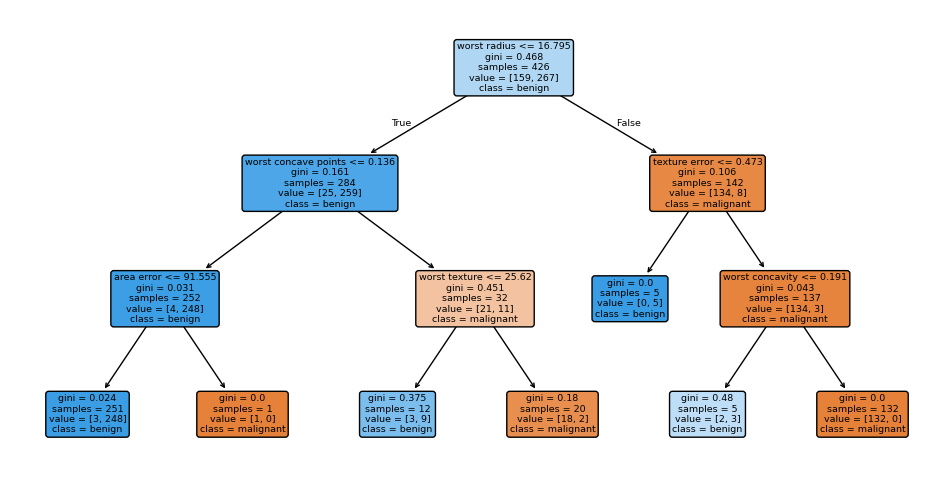

Entropy Tree:
Cross-validation scores: [0.91860465 0.94117647 0.89411765 0.92941176 0.97647059]
Mean CV accuracy: 0.9319562243502052
Standard deviation: 0.027140516744087056
Test accuracy: 0.951048951048951
--------------------------------------------------


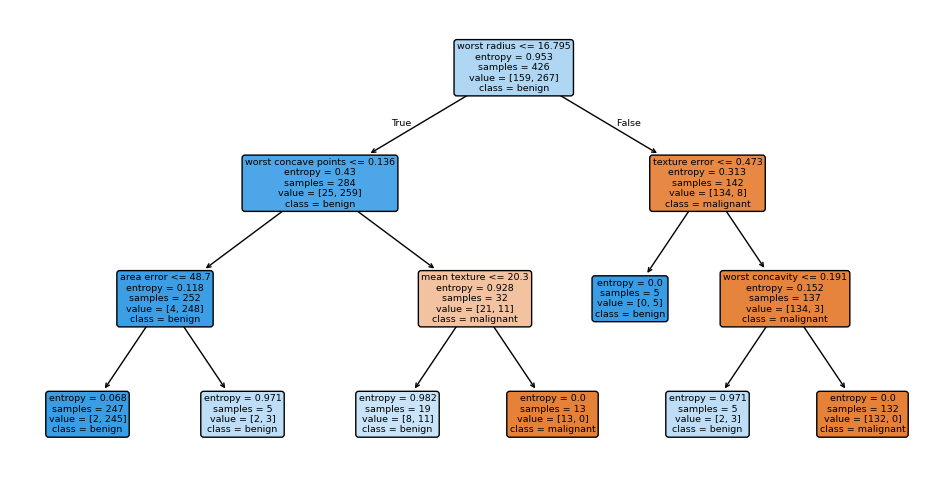

In [4]:
tree_depth = 3

#Initialize the gini and entropy trees
gini_tree = DecisionTreeClassifier(
criterion="gini",
max_depth=tree_depth,
random_state=42
)

entropy_tree = DecisionTreeClassifier(
criterion="entropy",
max_depth=tree_depth,
random_state=42
)

trees = {"Gini Tree": gini_tree, "Entropy Tree": entropy_tree}

cv_results = {}

for name, tree in trees.items():

    #Cross-validation on training data
    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    cv_results[name] = scores

    #Fitting final model on all training data
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test) 
    test_acc = accuracy_score(y_test, y_pred)
    
    print(f"{name}:")
    print("Cross-validation scores:", scores)
    print("Mean CV accuracy:", scores.mean())
    print("Standard deviation:", scores.std())
    print("Test accuracy:", test_acc)
    print("-" * 50)

    #Plot the two decision trees
    plt.figure(figsize=(12, 6))
    plot_tree(
    tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True
    )
    plt.show()

## Exploring Tree Depth

I used 6 different tree depths from 2 to 7 inclusive, and only entropy trees in an effort to keep experimental integrity.

The trees with depth 5 and 7 shared the top spot for highest 5-fold cross validation mean accuracy, at 95.3%. With depth 2 to 3, a 5% accuracy jump on final fitting to training data to 95% made the tree with depth 3 the most accurate, but that value went down as depth increased. I think the tree became harder to interpret because some of the branches near the end were asking questions about features being < 0.03, which I think is counterintuitive and potentially indicative of overfitting. This was a trend among other trees, as seen in the plots below. I would choose depth 4 or 5 because they seem to have the most natural questions (interpretability) and highest accuracies. 

There is also a dataframe table below the graphs that more cleanly explains the results.

Entropy Tree Depth 2:
Cross-validation scores: [0.87209302 0.94117647 0.87058824 0.91764706 0.95294118]
Mean CV accuracy: 0.9108891928864569
Standard deviation: 0.03423643447217388
Test accuracy: 0.9090909090909091
--------------------------------------------------


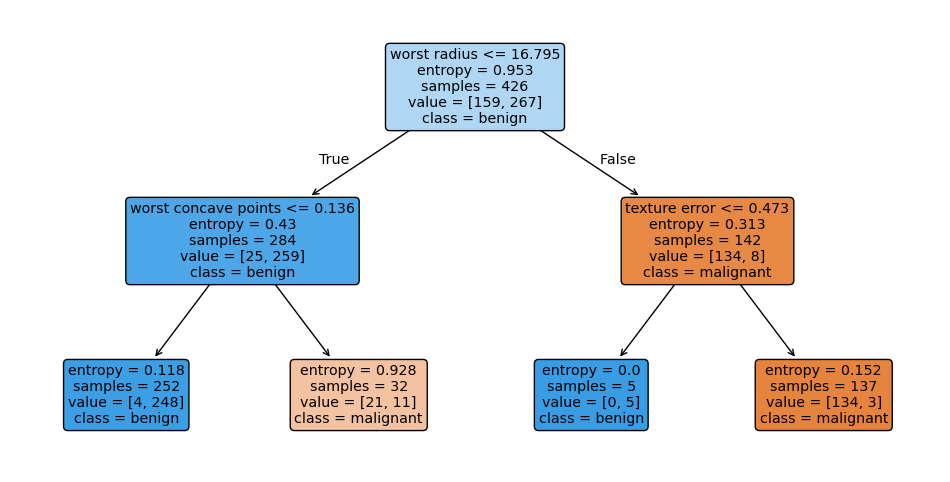

Entropy Tree Depth 3:
Cross-validation scores: [0.91860465 0.94117647 0.89411765 0.92941176 0.97647059]
Mean CV accuracy: 0.9319562243502052
Standard deviation: 0.027140516744087056
Test accuracy: 0.951048951048951
--------------------------------------------------


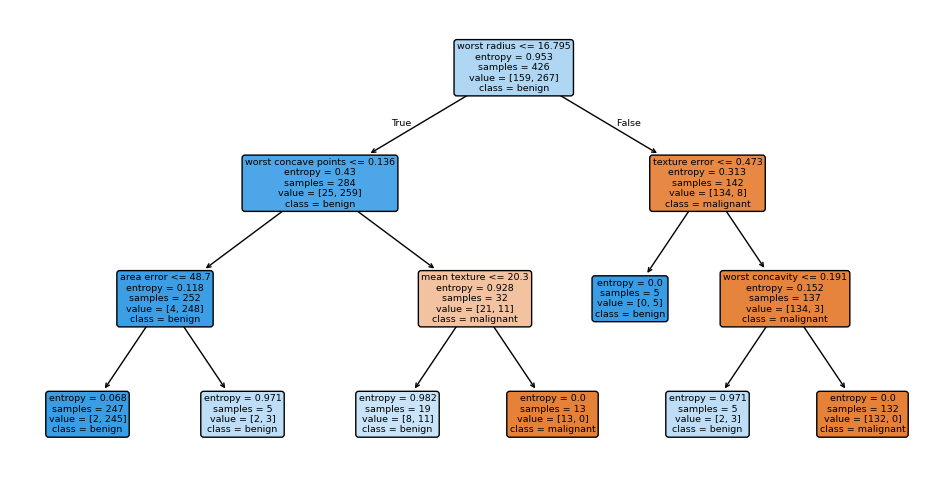

Entropy Tree Depth 4:
Cross-validation scores: [0.93023256 0.95294118 0.95294118 0.94117647 0.96470588]
Mean CV accuracy: 0.9483994528043777
Standard deviation: 0.01174190517932164
Test accuracy: 0.951048951048951
--------------------------------------------------


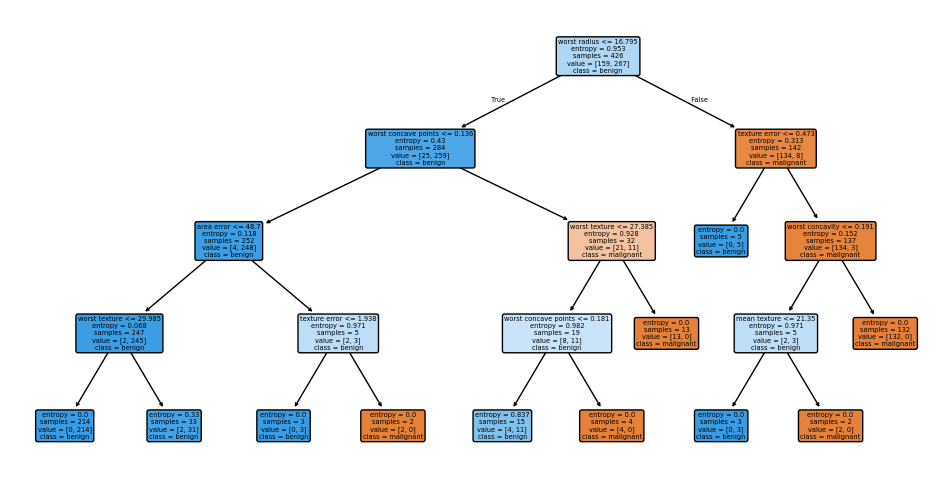

Entropy Tree Depth 5:
Cross-validation scores: [0.94186047 0.95294118 0.95294118 0.94117647 0.97647059]
Mean CV accuracy: 0.9530779753761971
Standard deviation: 0.012765031272237336
Test accuracy: 0.9370629370629371
--------------------------------------------------


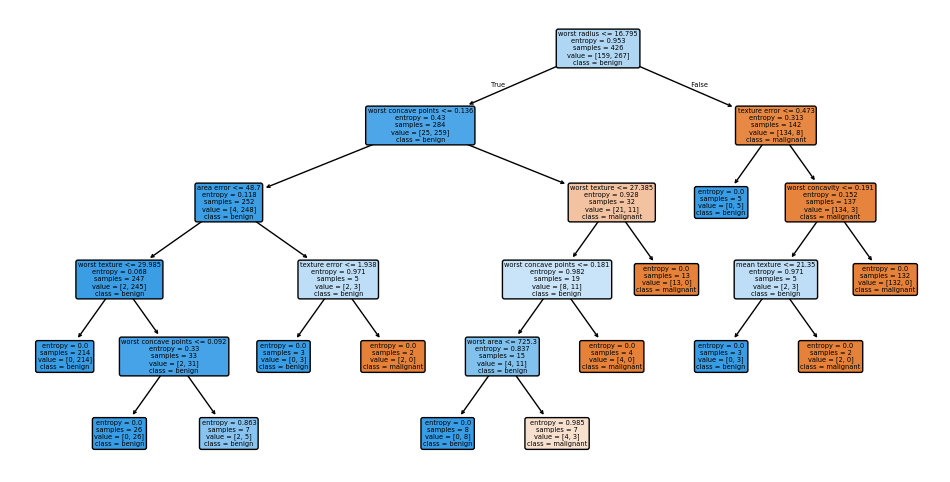

Entropy Tree Depth 6:
Cross-validation scores: [0.94186047 0.95294118 0.95294118 0.92941176 0.97647059]
Mean CV accuracy: 0.9507250341997265
Standard deviation: 0.015527344700754014
Test accuracy: 0.9300699300699301
--------------------------------------------------


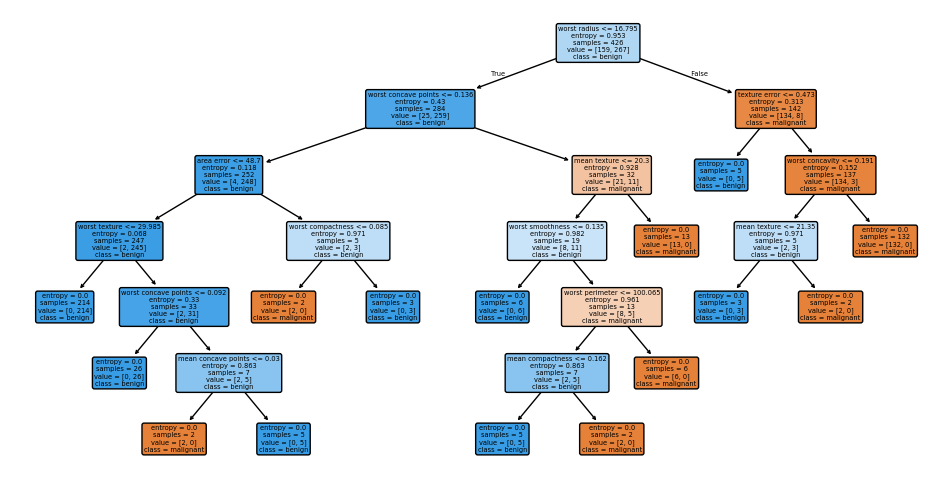

Entropy Tree Depth 7:
Cross-validation scores: [0.94186047 0.95294118 0.95294118 0.94117647 0.97647059]
Mean CV accuracy: 0.9530779753761971
Standard deviation: 0.012765031272237336
Test accuracy: 0.9300699300699301
--------------------------------------------------


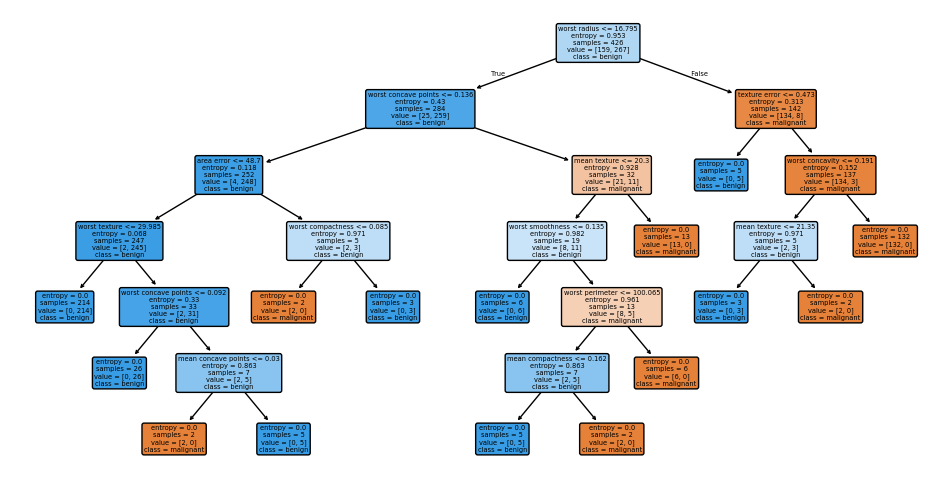

In [5]:
tree_depths = [2, 3, 4, 5, 6, 7]
entropy_trees = {}

#Create a dictionary with varying depth entropy trees
for i in range(0, 6):
    tree_name = f"Entropy Tree Depth {tree_depths[i]}"
    entropy_trees[tree_name] = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=tree_depths[i],
        random_state=42
    )

#Same loop as before
for name, tree in entropy_trees.items():
    #Cross-validation on training data
    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    cv_results[name] = scores

    #Fitting final model on all training data
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test) 
    test_acc = accuracy_score(y_test, y_pred)
    
    print(f"{name}:")
    print("Cross-validation scores:", scores)
    print("Mean CV accuracy:", scores.mean())
    print("Standard deviation:", scores.std())
    print("Test accuracy:", test_acc)
    print("-" * 50)

    #Plot the two decision trees
    plt.figure(figsize=(12, 6))
    plot_tree(
    tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True
    )
    plt.show()

In [6]:
depth_results = []

for name, tree in entropy_trees.items():
    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    depth_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "CV Std Dev": scores.std(),
        "Test Accuracy": test_acc
    })

depth_results_df = pd.DataFrame(depth_results)
depth_results_df

,Model,Mean CV Accuracy,CV Std Dev,Test Accuracy
0,Entropy Tree Depth 2,0.910889,0.034236,0.909091
1,Entropy Tree Depth 3,0.931956,0.027141,0.951049
2,Entropy Tree Depth 4,0.948399,0.011742,0.951049
3,Entropy Tree Depth 5,0.953078,0.012765,0.937063
4,Entropy Tree Depth 6,0.950725,0.015527,0.930070
5,Entropy Tree Depth 7,0.953078,0.012765,0.930070


## Tree Visualization, Analyzing an Entropy Tree

Plotted below is an entropy decision tree with max_depth 4.

The root of the tree asks whether worst radius <= 16.795. This is the first question the model uses to split the data, so it's what the model thinks is the most important first decision in this tree.

One branch is the right branch from the root. This branch represents tumors where worst radius > 16.795.
After taking this branch, the tree asks another question, is texture error <= 0.473?

A leaf occurs if the tumor follows this path:
worst radius > 16.795, and texture error <= 0.473

At this leaf, the predicted class is benign. This means that even though the tumor has a relatively large worst radius, if its texture error is very low, this particular tree predicts it as benign. This shows how the tree's inherent structure makes predictions as a sequence of yes/no decisions, starting from the root and ending at a leaf.

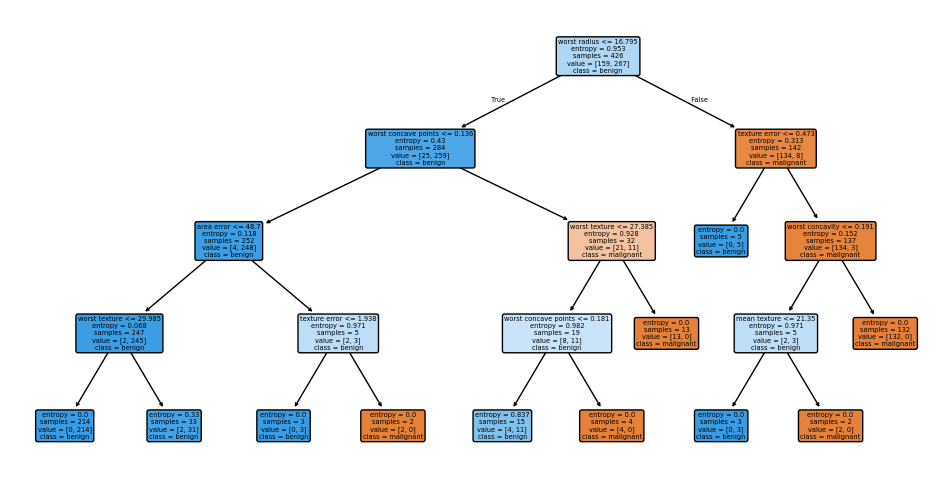

In [7]:
entropy_tree = DecisionTreeClassifier(
criterion="entropy",
max_depth=4,
random_state=42
)

entropy_tree.fit(X_train, y_train)
y_pred = entropy_tree.predict(X_test) 
test_acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(12, 6))
plot_tree(
    entropy_tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True
    )
plt.show()

## Final Reflection

I learned that decision trees were useful because they produce interpretable decision rules while still achieving strong classification accuracy. The main tradeoff was that deeper trees sometimes improved cross-validation accuracy, but they became harder to interpret and did not always improve test accuracy. A moderate depth, such as 3 or 4, seemed best because it balanced performance and readability. This result surprised me because a depth of 3 or 4 seems "small," but then it also made me think about how this dataset only has 30 dimensions. I'm sure that in a large dataset, a tree might have better performance with much more depth. However, the nonlinear nature of the (decision space?) of these trees makes me feel like I shouldn't trust my intuition with that question.